In [13]:
# Project 2: Laptop Price Predictor (Regression)
# Goal: Predict laptop prices with high accuracy using Random Forest

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Load the data
url = "https://raw.githubusercontent.com/campusx-official/laptop-price-predictor-regression-project/main/laptop_data.csv"
df = pd.read_csv(url)
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [14]:
# 1. Clean RAM (Remove 'GB' and convert to int)
df['Ram'] = df['Ram'].str.replace('GB', '').astype('int32')

# 2. Clean Weight (Remove 'kg' and convert to float)
df['Weight'] = df['Weight'].str.replace('kg', '').astype('float32')

# 3. Clean Memory (Extract the first numeric value, e.g., '128' from '128GB SSD')
df['Memory'] = df['Memory'].astype(str).str.extract('(\d+)').astype(float)

print("Numeric Data Cleaned!")
df[['Ram', 'Weight', 'Memory']].head()

Numeric Data Cleaned!


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3508920396.py:8: SyntaxWarning: invalid escape sequence '\d'
  df['Memory'] = df['Memory'].astype(str).str.extract('(\d+)').astype(float)


,Ram,Weight,Memory
0,8,1.37,128.0
1,8,1.34,128.0
2,8,1.86,256.0
3,16,1.83,512.0
4,8,1.37,256.0


In [15]:
# Extract CPU Brand
def fetch_processor(text):
    cpu_name = " ".join(text.split()[0:3])
    if cpu_name in ['Intel Core i7', 'Intel Core i5', 'Intel Core i3']:
        return cpu_name
    else:
        return 'AMD Processor' if text.split()[0] == 'AMD' else 'Other Intel Processor'

df['Cpu brand'] = df['Cpu'].apply(fetch_processor)

# Extract GPU Brand
df['Gpu brand'] = df['Gpu'].apply(lambda x: x.split()[0])
df = df[df['Gpu brand'] != 'ARM'] # Remove rare outlier

# Drop original complex columns that we have now 'simplified'
df.drop(columns=['Cpu', 'Gpu', 'ScreenResolution'], inplace=True)

df.head()

,Company,TypeName,Inches,Ram,Memory,OpSys,Weight,Price,Cpu brand,Gpu brand
0,Apple,Ultrabook,13.3,8,128.0,macOS,1.37,71378.6832,Intel Core i5,Intel
1,Apple,Ultrabook,13.3,8,128.0,macOS,1.34,47895.5232,Intel Core i5,Intel
2,HP,Notebook,15.6,8,256.0,No OS,1.86,30636.0000,Intel Core i5,Intel
3,Apple,Ultrabook,15.4,16,512.0,macOS,1.83,135195.3360,Intel Core i7,AMD
4,Apple,Ultrabook,13.3,8,256.0,macOS,1.37,96095.8080,Intel Core i5,Intel


In [16]:
# 1. Define Features (X) and Target (y)
X = df.drop(columns=['Price'])
y = np.log(df['Price']) # Using Log to normalize price distribution

# 2. Train-Test Split (85% to train, 15% to test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=2)

# 3. Define Categorical Columns for Encoding
cat_cols = ['Company', 'TypeName', 'Cpu brand', 'Gpu brand', 'OpSys']

# 4. Create Pipeline Steps
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

step2 = RandomForestRegressor(n_estimators=100, random_state=3, max_samples=0.5, max_features=0.75, max_depth=15)

# Build the final Pipeline
pipe = Pipeline([('step1', step1), ('step2', step2)])
print("Pipeline Created!")

Pipeline Created!


R2 Score: 0.8756
Mean Absolute Error: 0.1643


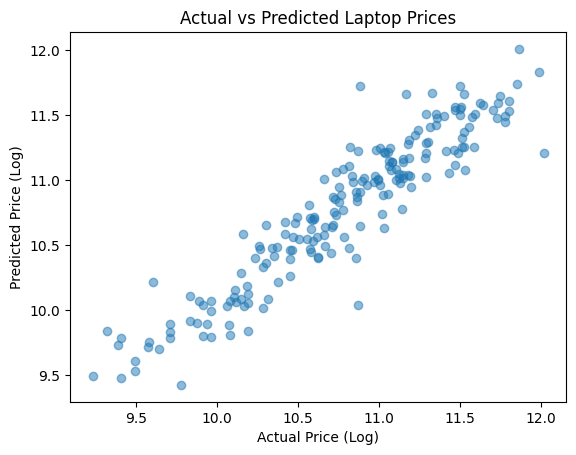

In [17]:
# Train the model
pipe.fit(X_train, y_train)

# Make Predictions
y_pred = pipe.predict(X_test)

# Results
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")

# Visualizing Predictions vs Actual
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Price (Log)')
plt.ylabel('Predicted Price (Log)')
plt.title('Actual vs Predicted Laptop Prices')
plt.show()